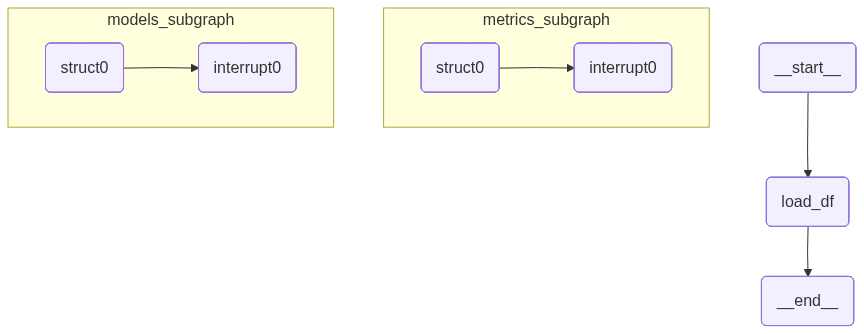

In [1]:
from state import MessagesState
from langgraph.types import interrupt
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage, SystemMessage
from config.config_dicts.null_handler import null_handler_config
from config.model import *

def build_hitl_subgraph(config: dict, orderlist: list):
    node_dict= {"analysis": 0, "struct": 0, "interrupt": 0, "update": 0}
    numbered_orderlist = []
    for node in orderlist:
        numbered_orderlist.append(node+str(node_dict[node]))
        node_dict[node]+=1
    def struct_node(state):
        # import pickle
        # with open("pickles/state.pkl", "rb") as f:
        #     loaded_state = pickle.load(f)

        node_count = int(numbered_orderlist[state['subgraph']][-1])
        current_struct = config['struct'][node_count] 
      
        model = current_struct['model']
        struct_model = model.with_structured_output(current_struct["schema"])

        message_template = current_struct["prompt"]
        context_demands = current_struct.get("context_demands",{})
        if context_demands != {}:
            prompt_string = ""
            for key,value in context_demands.items():
                prompt_string += str(state[key][value]) + "\n\n"
            human_message = message_template.format(context = prompt_string)
        else:
            human_message = message_template
        messages = [SystemMessage(content=prompt_generator(state, current_struct.get("data_demands",[]))), human_message]
        # return {"subgraph": 1, "struct": {"structresponse": "value"}}
        # options_dict = struct_model.invoke(messages)
        # struct_dict = state['struct']
        # struct_dict[current_struct["output_name"]] = options_dict.model_dump_json()
        # struct_dict[current_struct["output_name"]] = {"teststrudtnode": "value tsetlsekjl"}

        # try:
        #     import pickle
        #     with open("pickles/struct.pkl", "wb") as f:
        #         pickle.dump(state, f)
        # except Exception as e:
        #     print(f"Error at {e}")
        # return {"struct": options_dict.model_dump_json()}
        
        return {
            "struct": {"struct_dict": ""},
            "subgraph": state["subgraph"] + 1,
        }
        # else:
        #     return {
        #         "struct": struct_dict,
        #         "subgraph": 1
        #         }
        



    def ask_user_node(state):

        # try:
        #     import pickle
        #     with open("pickles/struct.pkl", "wb") as f:
        #         pickle.dump(state, f)
        # except Exception as e:
        #     print(f"Error at {e}")
        if config.get("interrupt_message", None):
            interrupt_message = config["interrupt_message"]
            n_rows = state['df_info']['n_rows']
            n_rows_20 = int(n_rows * 0.2)
            n_rows_10 = int(n_rows * 0.1)
            user_choice = interrupt({"interrupt_message": interrupt_message.format(n_rows=n_rows, n_rows_20=n_rows_20, n_rows_10=n_rows_10)})
        else:
            user_choice = interrupt({"struct": state.get("struct",{})})
        state_dict = state['user_choice']
        node_count = int(numbered_orderlist[state['subgraph']][-1])
        state_dict[config["interrupt_name"][node_count]] = user_choice
        return {
            "user_choice": state_dict,
            "subgraph": state["subgraph"] + 1,
        }
              
    graph_builder = StateGraph(MessagesState)
    node_dict = {
        "struct": struct_node,
        "interrupt": ask_user_node,
        "update": config.get("update", {}).get("method", None)
    }

    for i,node in enumerate(orderlist):
        graph_builder.add_node(numbered_orderlist[i],node_dict[node])

    for i,node in enumerate(numbered_orderlist):
        graph_builder.add_edge(START, node) if i == 0 else graph_builder.add_edge(numbered_orderlist[i-1],node)
    graph_builder.add_edge(numbered_orderlist[-1],END)

    graph = graph_builder.compile()
    return graph

from analyst.nodes import analyst_call
# from config.config_dicts.null_handler import null_handler_config
from config.config_dicts.metric_chooser import metrics_config
from config.config_dicts.model_chooser import models_config
# from config.nodes import preprocessor_call
from state import *
from langgraph.graph import StateGraph, START, END
from analyst.tools import tools_by_name as analyst_tools
from langgraph.checkpoint.memory import InMemorySaver
# from config.config_dicts.imbalance_handler import check_imbalance

# Build workflow
agent_builder = StateGraph(MessagesState)
analyst_tool_node = make_tool_node(analyst_tools)
# null_subgraph = build_hitl_subgraph(null_handler_config, ['struct','update'])
# imbalance_subgraph = build_hitl_subgraph(imbalance_config, ['struct','struct','interrupt'])
metrics_subgraph = build_hitl_subgraph(metrics_config, ['struct','interrupt'])
models_subgraph = build_hitl_subgraph(models_config, ['struct','interrupt'])
# Add nodes
# agent_builder.add_node("analyst", analyst_call)
# agent_builder.add_node("analyst_tools", analyst_tool_node)
# agent_builder.add_node("user_input",ask_user_node)
# agent_builder.add_node("null_subgraph", null_subgraph)
# agent_builder.add_node("check_imbalance", check_imbalance)
# agent_builder.add_node("imbalance_subgraph", imbalance_subgraph)
agent_builder.add_node("metrics_subgraph", metrics_subgraph)
agent_builder.add_node("models_subgraph", models_subgraph)
# agent_builder.add_node("subgraph_reset", subgraph_reset)
agent_builder.add_node("load_df",load_df)

# Add edges to connect nodes
# TEMPORARY
# agent_builder.add_edge(START, "analyst")
# agent_builder.add_conditional_edges(
#     "analyst",
#     should_continue,
#     ["analyst_tools", "null_subgraph"]
# )
# agent_builder.add_edge("analyst_tools", "analyst")

# agent_builder.add_edge(START, "null_subgraph")
# agent_builder.add_conditional_edges("check_imbalance", route_imbalance,["imbalance_subgraph","metric_subgraph"])
# agent_builder.add_edge("imbalance_subgraph", END)

agent_builder.add_edge(START, "load_df")
agent_builder.add_edge("load_df", END)

# agent_builder.add_edge("null_subgraph", "subgraph_reset")
# agent_builder.add_edge("subgraph_reset", "metrics_subgraph")
# agent_builder.add_edge("metrics_subgraph", END)

# Compile the agent
checkpointer = InMemorySaver()
agent = agent_builder.compile(checkpointer=checkpointer)

config = {
    "configurable": {
        "thread_id": "chat-1",
    }
}


# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))



In [4]:
# Stream (required for interrupt to work)
from langchain.messages import HumanMessage, SystemMessage
messages = [SystemMessage(content="start your task"),HumanMessage(content="Analyze the data")]

# Use stream() instead of invoke() to enable input() functionality
for chunk in agent.stream({"messages": messages, "subgraph": 0, "user_choice": {}, "struct": {}, "df_info": {"target": "Label", "filepath": "/home/youssef/Documents/python/higgs/training.csv", "data_description": ""}}, config): 
    # Process each chunk as it arrives
    for node_name, node_output in chunk.items():
        print(f"\n[{node_name}]")
        if node_name == "__interrupt__":
            interrupt_payload = node_output
            break
        if "messages" in node_output and len(node_output["messages"]) > 0:
            last_message = node_output["messages"][-1]
            if hasattr(last_message, "content") and last_message.content:
                print(f"Content: {last_message.content}")
            if hasattr(last_message, "tool_calls") and last_message.tool_calls:
                print(f"Tool calls: {last_message.tool_calls}")
        else:
            print(f"Output: {node_output}")

/home/youssef/Documents/python/ml-assistant/state.py:305: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  outlier_count = int(((df < lower) | (df > upper)).sum())
/home/youssef/Documents/python/ml-assistant/state.py:305: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  outlier_count = int(((df < lower) | (df > upper)).sum())
/home/youssef/Documents/python/ml-assistant/state.py:305: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  outlier_count = int(((df < lower) | (df > upper)).sum())
/home/youssef/Documents/python/ml-assistant/state.py:305: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  outlier_count = int(((df < lower)


[load_df]
Output: {'df_info': {'target': 'Label', 'filepath': '/home/youssef/Documents/python/higgs/training.csv', 'data_description': '', 'n_rows': 250000, 'n_cols (without target)': 32, 'numeric_features': {32: ['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality', 'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi', 'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi', 'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt', 'Weight']}, 'categorical_features': {0: []}, 'null_counts': {'EventId': 0, 'DER_mass_MMC': 0, 'DER_mass_transverse_met_lep': 0, 'DER_mass_vis': 0, 'DER_pt_h': 0, 'DER_deltaeta_jet_jet': 0, 'DER_mas

/home/youssef/Documents/python/ml-assistant/state.py:305: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  outlier_count = int(((df < lower) | (df > upper)).sum())


In [4]:
import pickle
with open("pickles/metrics.pkl", "rb") as f:
    loaded_state = pickle.load(f)

# print(loaded_state['analysis'])
# loaded_state['struct']
# print(loaded_state['struct']['null0'])
# loaded_state['struct']['null1']
loaded_state

{'messages': [SystemMessage(content='start your task', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={}),
  SystemMessage(content='start your task', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={})],
 'struct': {},
 'analysis': [],
 'user_choice': {},
 'update': [],
 'subgraph': 0,
 'original_df': {'PassengerId': {0: 1,
   1: 2,
   2: 3,
   3: 4,
   4: 5,
   5: 6,
   6: 7,
   7: 8,
   8: 9,
   9: 10,
   10: 11,
   11: 12,
   12: 13,
   13: 14,
   14: 15,
   15: 16,
   16: 17,
   17: 18,
   18: 19,
   19: 20,
   20: 21,
   21: 22,
   22: 23,
   23: 24,
   24: 25,
   25: 26,
   26: 27,
   27: 28,
   28: 29,
   29: 30,
   30: 31,
   31: 32,
   32: 33,
   33: 34,
   34: 35,
   35: 36,
   36: 37,
   37: 38,
   38: 39,
   39: 40,
   40: 41,
   41: 42,
   42: 43,
   43: 44,
   44: 45,
   45: 46,
   46: 47,
   47: 48,
   48: 49,
  

In [9]:
from langgraph.types import Command

# config = {"configurable": {"thread_id": "chat-1"}}

# # First run: hits interrupt and pauses
# result = agent.invoke({"input": "hi"}, config=config)
# print(result["__interrupt__"])

# Resume: this continues, and interrupt() returns this value

agent.invoke(Command(resume=

{
    # "drop_column": ["Cabin"],
    # "drop_rows": ["Embarked"],
    # "fill_with_average": ["Age"]

    "metrics": ["f1", "recall", "precision"]
}

),config=config)

{'messages': [SystemMessage(content='start your task', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={}),
  SystemMessage(content='start your task', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={})],
 'struct': {'met0': '{"reasoning":"The dataset contains information about Titanic passengers, including whether they survived or not. This is a binary classification problem, where the goal is to predict survival. Accuracy is a common metric for binary classification, but it can be misleading if the classes are imbalanced. Precision and recall are useful when the cost of false positives or false negatives, respectively, is high. ROC AUC is a good metric for evaluating the overall performance of a classifier across different thresholds. Given the potential for class imbalance (more non-survivors than survivors based on the class

In [8]:
import json
json.loads(interrupt_payload[0].value['struct']['met0'])

{'reasoning': 'The dataset contains information about Titanic passengers, including whether they survived or not. This is a binary classification problem, where the goal is to predict survival. Accuracy is a common metric for binary classification, but it can be misleading if the classes are imbalanced. Precision and recall are useful when the cost of false positives or false negatives, respectively, is high. ROC AUC is a good metric for evaluating the overall performance of a classifier across different thresholds. Given the potential for class imbalance (more non-survivors than survivors based on the class distribution), ROC AUC, precision, and recall are strong candidates for evaluation. Accuracy can also be considered, but with a caution about class imbalance.',
 'actions': {'True': ['roc-auc', 'precision', 'recall'],
  'False': ['accuracy', 'f1']},
 'prompts': ["For this binary classification task predicting passenger survival, I recommend using ROC AUC, precision, or recall as ev